- supervisor сам решает кого вызвать и в каком порядке
- каждый агент — полноценный ReAct-агент с LLM внутри
- коммуникация через граф сообщений LangGraph


In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import re
import json
import base64
from pathlib import Path
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent
from langgraph_supervisor import create_supervisor

load_dotenv()

True

**План файлов**

| № | Файл | Описание |
|---|------|----------|
| 1 | `index.html` | Главная страница. Содержит заголовок, блок загрузки, контейнер для прогноза из трёх дней и подключает CSS и JS. |
| 2 | `styles.css` | Стили для заголовка, блока прогноза, дней и индикатора загрузки. |
| 3 | `main.js` | Скрипт, который:<br>• Получает API‑ключ через `get_api_key()`<br>• Делает запрос к OpenWeatherMap API (Москва, 3 дня, температура в °C)<br>• Группирует данные по дате, рассчитывает среднюю температуру и выводит в DOM. |

Если всё согласовано, я могу перейти к реализации и сохранению файлов.

============================================================
Созданные файлы:
   • index.html
   • main.js
   • style.css

Открыть проект: file:///scripts/demo_06/index.html

In [8]:
OUTPUT_DIR = Path(os.getenv("OUTPUT_DIR", "../scripts/demo_03"))
DOCKER_DIR = OUTPUT_DIR / "docker"

if OUTPUT_DIR.exists():
    for f in OUTPUT_DIR.iterdir():
        if f.is_file():
            f.unlink()
    print(f"Папка очищена: {OUTPUT_DIR}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if DOCKER_DIR.exists():
    for f in DOCKER_DIR.iterdir():
        if f.is_file():
            f.unlink()
    print(f"Папка очищена: {DOCKER_DIR}")
DOCKER_DIR.mkdir(parents=True, exist_ok=True)

model = ChatOpenAI(
    base_url=os.getenv("OPENAI_API_HOST"),
    api_key=os.getenv("OPENAI_API_KEY"),
    model="Qwen/Qwen3.5-27B",
    timeout=120,
    temperature=0.7,
    extra_body={"chat_template_kwargs": {"enable_thinking": False}},
)

# ── Утилиты ───────────────────────────────────────────────────────────────────

def extract_filename(text: str) -> str | None:
    match = re.search(
        r'[\w\-]+\.(html|css|js|json|md|txt|yml|yaml|env|example|dockerignore)|Dockerfile',
        text, re.IGNORECASE)
    return match.group(0) if match else None

def save_file(filename: str, content: str) -> str:
    content = re.sub(r'^```[\w]*\n?', '', content.strip())
    content = re.sub(r'\n?```$', '', content.strip())
    filepath = OUTPUT_DIR / filename
    filepath.write_text(content, encoding="utf-8")
    print(f"   💾 Сохранено: {filepath}")
    return str(filepath)

def save_file_docker(filename: str, content: str) -> str: 
    content = re.sub(r'^```[\w]*\n?', '', content.strip())
    content = re.sub(r'\n?```$', '', content.strip())
    filepath = DOCKER_DIR / filename
    filepath.write_text(content, encoding="utf-8")
    print(f"   💾 Сохранено: {filepath}")
    return str(filepath)


# ── Инструменты для агентов ───────────────────────────────────────────────────

@tool
def create_plan(query: str) -> str:
    """Создать план разработки веб-приложения. Возвращает JSON-список файлов."""
    from langchain_core.messages import SystemMessage, HumanMessage
    messages = [
        SystemMessage(content="""Ты — старший планировщик проектов.
Разбей задачу на конкретные файлы. Отвечай ТОЛЬКО валидным JSON массивом.
Каждый элемент: {"filename": "имя файла", "description": "что должно быть внутри"}

ВАЖНО:
- каждый файл ровно один раз
- максимум один js-файл (main.js)
- сначала index.html со всеми id-элементами
- в описаниях css/js указывай какие id/классы использовать из index.html
- в main.js разработчик получит API ключ через инструмент get_api_key"
"""),
        HumanMessage(content=query)
    ]
    result = model.invoke(messages)
    return result.content


@tool
def write_file(description: str) -> str:
    """Написать содержимое одного файла по его описанию. Возвращает готовый код."""
    from langchain_core.messages import SystemMessage, HumanMessage
    messages = [
        SystemMessage(content="""Ты — старший веб-разработчик.
Получаешь описание файла — возвращаешь ТОЛЬКО готовое содержимое файла.
Никаких пояснений, никакого markdown."""),
        HumanMessage(content=description)
    ]
    result = model.invoke(messages)
    return result.content

@tool
def get_api_key() -> str:
    """
    Получить API ключ для OpenWeatherMap в зашифрованном виде.
    Используй когда нужно вставить API_KEY в main.js.
    Возвращает имя переменной и способ её расшифровки в JS коде.
    """
    raw_key = os.getenv("WEATHER_API_KEY", "")
    if not raw_key:
        return "Ошибка: WEATHER_API_KEY не найден в .env"
    
    encoded = base64.b64encode(raw_key.encode()).decode()
    
    js_snippet = f"""// Вставь этот код в начало main.js:
const _k = atob("{encoded}");
// Используй _k вместо API_KEY в запросах к OpenWeatherMap
"""
    print(f"[get_api_key] Ключ зашифрован и передан разработчику")
    return js_snippet


@tool
def save_project_file(filename: str, content: str) -> str:
    """Сохранить файл проекта на диск. Принимает имя файла и его содержимое."""
    saved = save_file(filename, content)
    return f"Файл {filename} сохранён: {saved}"


@tool
def write_docker_file(filename: str, description: str) -> str:
    """Написать содержимое одного Docker-файла (Dockerfile, docker-compose.yml, requirements.txt и т.д.).
    Аргументы: filename — имя файла, description — подробное ТЗ.
    Возвращает готовое содержимое файла.
    """
    from langchain_core.messages import SystemMessage, HumanMessage
    messages = [
        SystemMessage(content="""Ты — Senior DevOps инженер. Пишешь файлы для Docker.
Получаешь имя файла и описание — возвращаешь ТОЛЬКО содержимое файла.
Никаких пояснений, никакого markdown, никаких ``` обёрток.
Требования:
- Dockerfile: python:3.11-slim, --no-cache-dir, EXPOSE 8888, JupyterLab как CMD
- requirements.txt: реальные пакеты с версиями
- docker-compose.yml: version 3.9, volumes для live reload, profiles для headless-запуска"""),
        HumanMessage(content=f"Файл: {filename}\nОписание: {description}")
    ]
    result = model.invoke(messages)
    content = result.content
    content = re.sub(r'^```[\w]*\n?', '', content.strip())
    content = re.sub(r'\n?```$', '', content.strip())
    print(f"   ✍️  {filename}: написан ({len(content)} символов)")
    return content


@tool
def save_docker_file(filename: str, content: str) -> str: 
    """Сохранить Docker-файл на диск в папку docker. Принимает имя файла и его содержимое."""
    saved = save_file_docker(filename, content)
    return f"Файл {filename} сохранён: {saved}"


planner_agent = create_react_agent(
    model=model,
    tools=[create_plan],
    prompt="Ты — агент-планировщик. Вызови create_plan и верни JSON-план файлов проекта.",
    name="planner_agent",
)

developer_agent = create_react_agent(
    model=model,
    tools=[write_file, save_project_file, get_api_key],
    prompt="""Ты — агент-разработчик. Получаешь план в виде JSON-списка файлов.
Для каждого файла:
1. Если файл main.js — сначала вызови get_api_key чтобы получить зашифрованный ключ
2. Вызови write_file с описанием файла (включи в описание полученный js_snippet)
3. Вызови save_project_file с именем файла и содержимым
Обработай ВСЕ файлы из плана.""",
    name="developer_agent",
)

executor_agent = create_react_agent(
    model=model,
    tools=[write_docker_file, save_docker_file],
    prompt="""Ты — DevOps-разработчик. Твоя задача — создать файлы для Docker-деплоя.

Создай СТРОГО ЭТИ файлы по порядку, для каждого:
1. Вызови write_docker_file(filename, description)
2. Вызови save_docker_file(filename, content)

Список файлов:
- filename: "Dockerfile", description: "python:3.11-slim, устанавливает зависимости из requirements.txt, запускает JupyterLab на порту 8888"
- filename: "requirements.txt", description: "пакеты: langchain, langchain-openai, langgraph, langgraph-supervisor, python-dotenv, jupyterlab"
- filename: "docker-compose.yml", description: "version 3.9, сервис jupyter с volume ./notebooks и портом 8888, env_file: .env"
- filename: ".env.example", description: "переменные OPENAI_API_HOST, OPENAI_API_KEY, WEATHER_API_KEY с пустыми значениями и комментариями"
- filename: ".dockerignore", description: ".env, __pycache__, *.pyc, .git"

Обработай ВСЕ 5 файлов без исключений.""",
    name="docker_developer_agent",
)

workflow = create_supervisor(
    agents=[planner_agent, developer_agent, executor_agent],
    model=model,
    prompt="""Ты — менеджер команды разработки. Строго по порядку:
1. Сначала planner_agent — создаст план файлов
2. Затем developer_agent — напишет и сохранит файлы относящиеся к фронту.
3. После docker_developer_agent - напишет и сохранит все файлы для докера

НЕ пропускай ни одного агента. После выполнения developer_agent ОБЯЗАТЕЛЬНО вызови docker_developer_agent.
Не завершай работу, пока все три агента не будут вызваны по одному разу."""
)

app = workflow.compile()

# ── Запуск ────────────────────────────────────────────────────────────────────
        
query = """Создай веб-приложение, которое показывает погоду в Москве 
на ближайшие 3 дня. Данные бери с openweathermap.org."""

print("\nЗапуск мультиагентной системы (LangGraph Supervisor)...")
print("=" * 60)

result = app.invoke({
    "messages": [{"role": "user", "content": query}]},
    config={"recursion_limit": 50})

# for event in app.stream({"messages": [{"role": "user", "content": query}]}):
#     print(event)

print(result['messages'][-1].content)

print("\n" + "=" * 60)
saved = list(OUTPUT_DIR.iterdir())
if saved:
    print("Созданные файлы:")
    for f in saved:
        print(f"   • {f.name}")
    index = OUTPUT_DIR / "index.html"
    if index.exists():
        print(f"\nОткрыть проект: file:///{index.as_posix()}")
    else:
        print(f"\nПапка проекта: file:///{OUTPUT_DIR.as_posix()}")

saved_docker = list(DOCKER_DIR.iterdir())
if saved_docker:
    print("\nDocker-файлы:")
    for f in saved_docker:
        print(f"   • {f.name}")

Папка очищена: ../scripts/demo_06
Папка очищена: ../scripts/demo_06/docker

Запуск мультиагентной системы (LangGraph Supervisor)...
   💾 Сохранено: ../scripts/demo_06/index.html
   💾 Сохранено: ../scripts/demo_06/style.css
[get_api_key] Ключ зашифрован и передан разработчику
   💾 Сохранено: ../scripts/demo_06/main.js
   💾 Сохранено: ../scripts/demo_06/index.html
   ✍️  Dockerfile: написан (266 символов)
   💾 Сохранено: ../scripts/demo_06/docker/Dockerfile
   ✍️  requirements.txt: написан (127 символов)
   💾 Сохранено: ../scripts/demo_06/docker/requirements.txt
   ✍️  docker-compose.yml: написан (189 символов)
   💾 Сохранено: ../scripts/demo_06/docker/docker-compose.yml
   ✍️  .env.example: написан (120 символов)
   💾 Сохранено: ../scripts/demo_06/docker/.env.example
   ✍️  .dockerignore: написан (168 символов)
   💾 Сохранено: ../scripts/demo_06/docker/.dockerignore
Все три этапа разработки успешно завершены:

1.  **planner_agent** создал план структуры файлов.
2.  **developer_agent** н

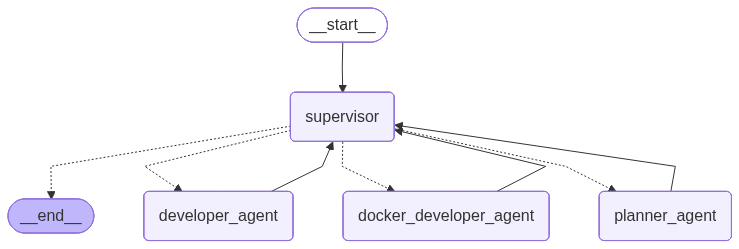

In [5]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

localhost:8080